# Linear Unmixing of Spectral Fluorescence Microscopy Data from Astrocytes and Neurons dataset

In this notebook we perform linear unmixing on spectral data from Fluorescence Microscopy.

In this case, for a given pixel, we suppose to have a set of intensity measurements at different wavelengths, e.g., $y = [y(\lambda_1),y(\lambda_2),\dots,y(\lambda_n)]$, with $n=32$ for instance. For each one of these spectral bands $\lambda_i$, with $i=1,\dots,n$, and for each fluorophore $f$, with $f=1,\dots,m$, we assume the reference spectra $R_f=[R_f(\lambda_1), R_f(\lambda_2), \dots, R_f(\lambda_n)]$ to be known. 

### 1. Data Preparation

Load mixed image & metadata:

In [1]:
from data import AstroNeuronData

DATA_DIR = '/group/jug/federico/data/neurons_and_astrocytes/'
data = AstroNeuronData(
    data_dir=DATA_DIR,
    idx=0,
    dset_type="astrocytes",
    groups=["control"],
    dim="2D",
)

In [2]:
N = len(data)
F = len(data.metadata["structures"])
print(data)

-------------------------
GT Image Shape: (7, 1688, 1688)
Mixed Image Shape: (28, 1688, 1688)
-------------------------
Metadata:
+ structures: ['LipidDroplets', 'ER', 'Peroxisomes', 'Golgi', 'Mitochondria', 'Lysosomes']
+ fluorophores: ['BODIPY 650_665', 'mApple', 'mOrange2', 'Venus', 'avGFP', 'mTurquoise']
+ num_bins: 28
+ bin_width_nm: 9.7
+ voxel_size_um: [0.08, 0.08, 0.41]
+ light_wavelengths: [458, 514, 561, 633]
+ wavelength_range: [446, 695]
+ dtype: uint16



Get reference spectra from `FPBase` using `microsim` API:

In [3]:
from data.FPData import FPRefMatrix

fps = data.metadata["fluorophores"]
w_bins = data.mixed_img.shape[0]
w_range = data.metadata["wavelength_range"]
fp_ref_matrix = FPRefMatrix(fps, w_bins, w_range)
fp_ref_matrix = fp_ref_matrix.create()

**OBSERVATION**
The mixed image is a 16bit image (range: 0-6.5e4), whereas the intensity of fluorophores emission spectra ranges in 0-1 before the binning.

Intuitively, intensity ranges should be the same. However does this really matter?

In my understanding, the answer is NO. Let's see why:

- Suppose the case of 0-1 range normalization. In that case, normalization is obtained by simply dividing each pixel's intensity by the maximum intensity in the image. In other terms we basically divide by a scalar. Therefore, supposing that we normalize in this way both the mixed image and the reference spectra, the linear system becomes:

\begin{equation}
\frac{1}{k_I}y = \frac{1}{k_R}\mathbf{R}c
\end{equation}

where $k_I$ and $k_R$ are scalar. Therefore the solution of this system is the same up to some multiplicative constants.

Therefore, we can normalize everything in the range 0-1 so that quantities are in the same scale.

### 2. Compute the LS solution

In [4]:
from methods import LeastSquares

# Solving LS for digital image
ls = LeastSquares(data.mixed_img, fp_ref_matrix)
fp_conc_img_LS = ls.solve(progr_bar=True)

Solving LS for pixel: 100%|██████████| 2849344/2849344 [01:55<00:00, 24615.37it/s]


In [5]:
# from methods import FCLSU

# fclsu = FCLSU(data.mixed_img, fp_ref_matrix)
# fp_conc_img_FCLSU = fclsu.solve()

### 3. Visualizing results

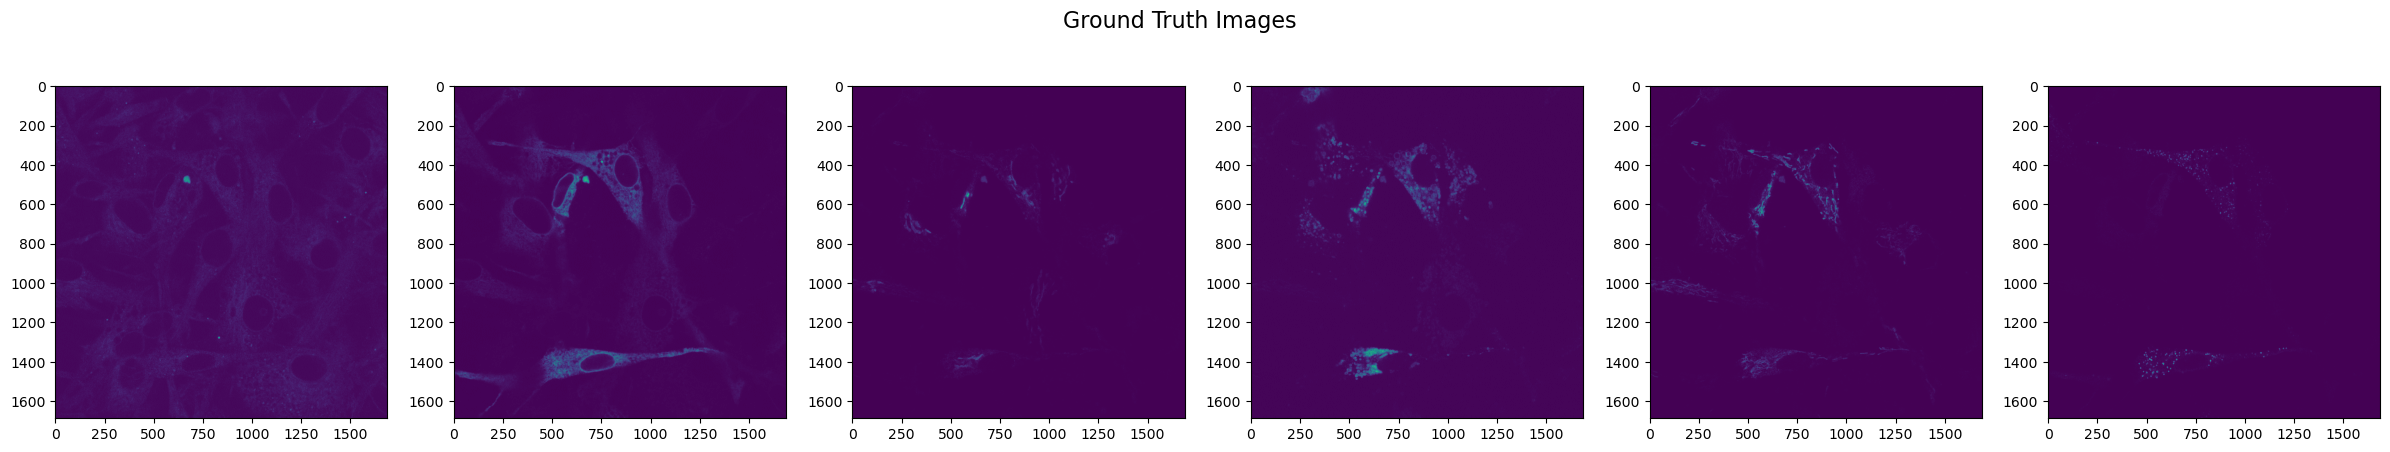

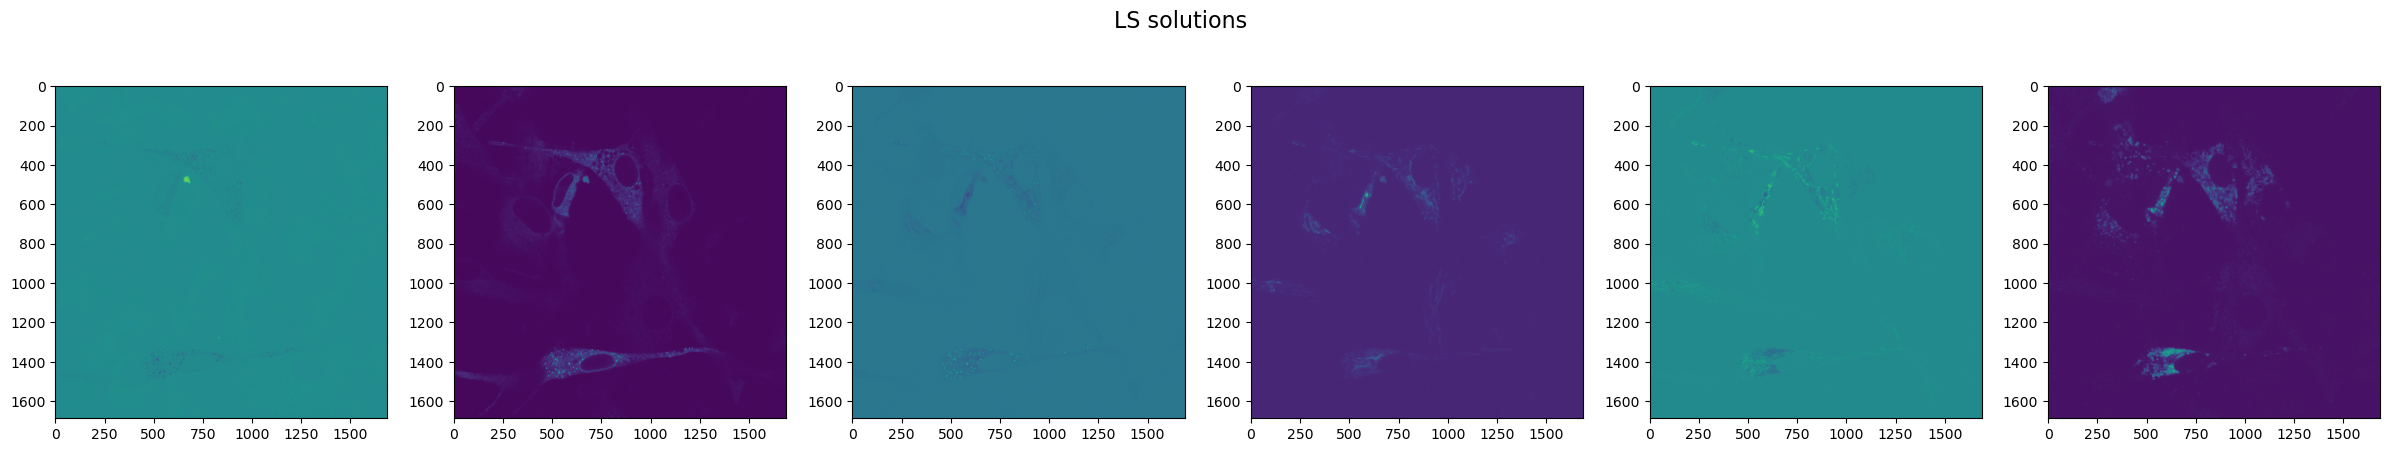

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, F, figsize=(5*F, 5))
fig.suptitle("Ground Truth Images", fontsize=16)
for i in range(F):
    ax[i].imshow(data.gt_img[i, ...])

fig, ax = plt.subplots(1, F, figsize=(5*F, 5))
fig.suptitle("LS solutions", fontsize=16)
for i in range(F):
    ax[i].imshow(fp_conc_img_LS[i, :, :])
    
# fig, ax = plt.subplots(1, F, figsize=(5*F, 5))
# fig.suptitle("FCLSU solutions", fontsize=16)
# for i in range(F):
#     ax[i].imshow(fp_conc_img_FCLSU[i, :, :])

### 4. Evaluation

Compute error with respect to ground truth images for each flurophore.

The ground truth images are `(Z, Y, X)` arrays, which correspond to the clean image that we would get from one FP alone.

Observe that the solution of the linear unmixing problem expresses **concentrations** of FPs, whereas the GT microscope images express values as intensities. <br>
A way to compare these quantities is by using the **Range Invariant PSNR**, which is independent of the scale of the involved quantities.   

Here, we compute the overall error for each FP as the Range Invariant PSNR and visualize it:

LS PSNR: 32.383346, 34.850586, 38.371213, 29.726161, 34.838810, 37.278069


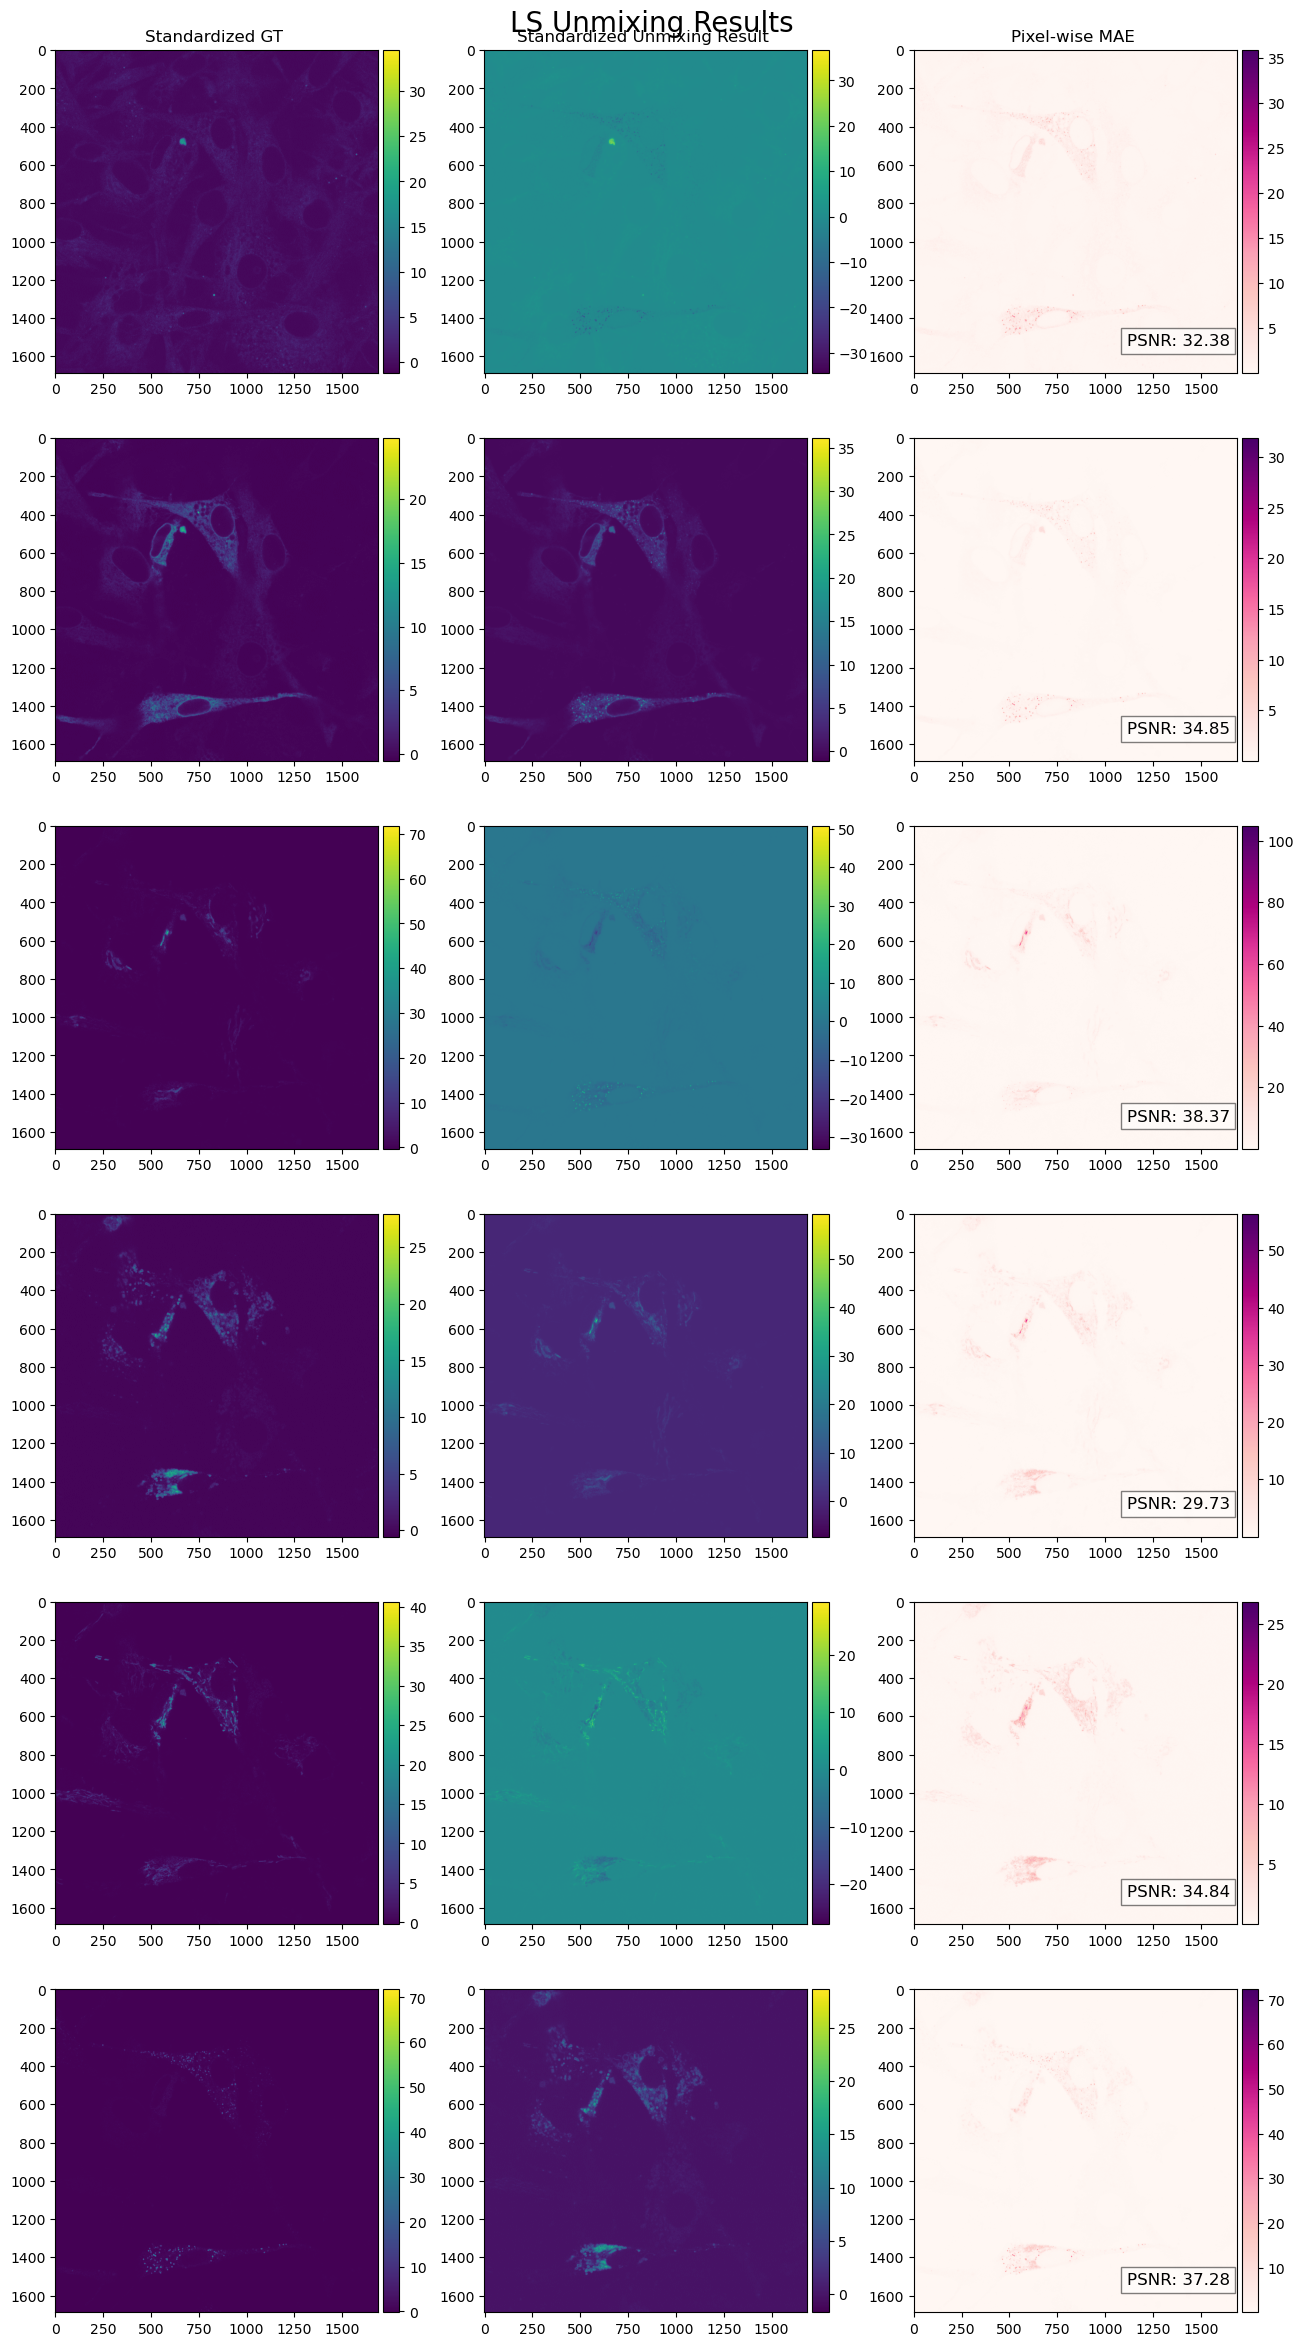

In [7]:
from utils.plots import plot_unmixed_vs_gt

plot_unmixed_vs_gt(
    gt_img=data.gt_img[:6],
    unmixed_img=fp_conc_img_LS,
    method="LS",    
)

In [8]:
# plot_unmixed_vs_gt(
#     gt_img=data.gt_img,
#     unmixed_img=fp_conc_img_FCLSU,
#     method="FCLSU",    
# )

#### 5. Run LU & Evaluate on the enitre dataset

In [9]:
from tqdm import tqdm

from utils.metrics import RangeInvariantPSNR

In [10]:
psnr = []
for i in tqdm(range(N)):
    curr_data = AstroNeuronData(
    data_dir=DATA_DIR,
    idx=i,
    dset_type="astrocytes",
    groups=["control"],
    dim="2D",
)
    ls = LeastSquares(curr_data.mixed_img, fp_ref_matrix)
    unmixed_img = ls.solve(progr_bar=False)
    curr_psnr = []
    for j in range(F):
        curr_psnr.append(
            RangeInvariantPSNR(curr_data.gt_img[j, ...], unmixed_img[j, ...])
        )
    psnr.append(curr_psnr)

100%|██████████| 30/30 [54:02<00:00, 108.08s/it]


In [11]:
import numpy as np

psnr = np.asarray(psnr)
results = psnr.mean(axis=0)
for i in range(F):
    print(f"FP#{i+1} PSNR: {results[i]:.2f}")
print(f"Mean PSNR: {results.mean():.2f}")  

FP#1 PSNR: 33.61
FP#2 PSNR: 38.12
FP#3 PSNR: 37.07
FP#4 PSNR: 32.38
FP#5 PSNR: 35.96
FP#6 PSNR: 37.17
Mean PSNR: 35.72
